## **Лабораторная работа "Прогнозирование"**

**Задача:** Построить прогноз на 8 месяцев.

**Общее описание данных:**

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics.
Данные собирались ежемесячно с января 1994 по апрель 2003.

**Вариант 2:** Средняя цена номера в отеле в долларах (Average Daily Rate (in $)). Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения цены за один день. Усреднение по отелям и по дням месяца.

Данные расположены в столбце x2 файла Chicago_hotels.csv

In [104]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [1]:
# Загружаем данные
!gdown 1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz

Downloading...
From: https://drive.google.com/uc?id=1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz
To: /content/Chicago_hotels.csv
100% 4.22k/4.22k [00:00<00:00, 9.90MB/s]


In [9]:
df = pd.read_csv('Chicago_hotels.csv', sep=';', decimal=',', na_values = " ")
df.head()

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   120 non-null    object 
 1   date2   120 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.8+ KB


In [11]:
df.tail(10)

,date1,date2,x1,x2,x3,x4
110,March,2003,65.0,147.32,55.9,99.62
111,April,2003,69.0,150.72,58.4,101.32
112,May,2003,NaN,NaN,NaN,NaN
113,June,2003,NaN,NaN,NaN,NaN
114,July,2003,NaN,NaN,NaN,NaN
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN
119,December,2003,NaN,NaN,NaN,NaN


Замечаем, что есть пропуски в данных, это месяцы, которые мы будем прогнозировать. Для построения модели будем использовать только наблюдаемую часть ряда без пропусков.

In [13]:
data = df.iloc[:112]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


Прогнозируем cреднюю цену номера в отеле в долларах (Average Daily Rate (in $)) - переменная x2

In [15]:
y = data['x2']

In [ ]:
# Установим даты
data['date'] = data['date1'] + ' ' + data['date2'].astype(str)
data['date'] = pd.to_datetime(data['date'])

data = data.set_index('date')

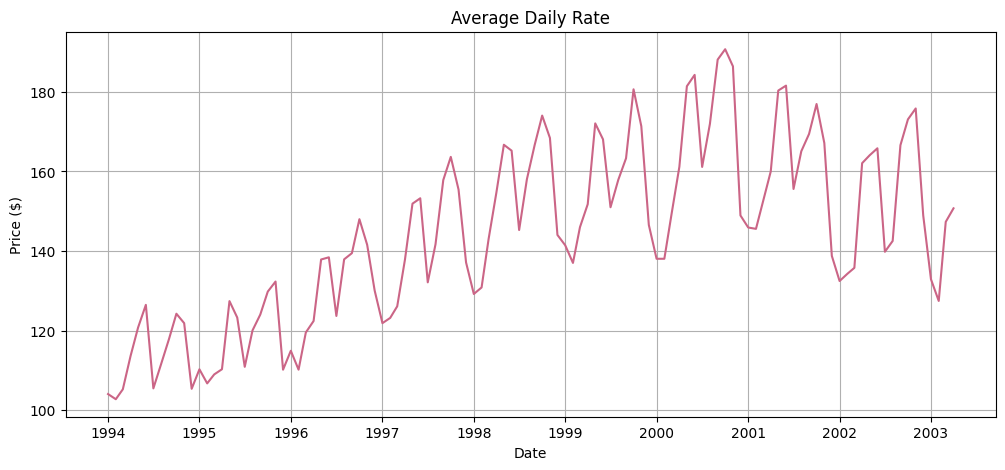

In [66]:
# Построим график временного ряда
y = data['x2']

plt.figure(figsize=(12,5))
plt.plot(y, color = '#CB6586')
plt.title('Average Daily Rate')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.style.use('ggplot')
plt.grid()
plt.show()

По графику временного ряда наблюдается линейный тренд и годовая сезонность. Амплитуда сезонных колебаний увеличивается со временем, что указывает на мультипликативный характер сезонности.

In [ ]:
# Строим модель прогнозирования
fit = ExponentialSmoothing(np.asarray(y), seasonal_periods=12, trend='additive',
                            seasonal='multiplicative', damped = True).fit()

In [91]:
# Прогнозные значения
fitted_ = fit.predict(0, 119)

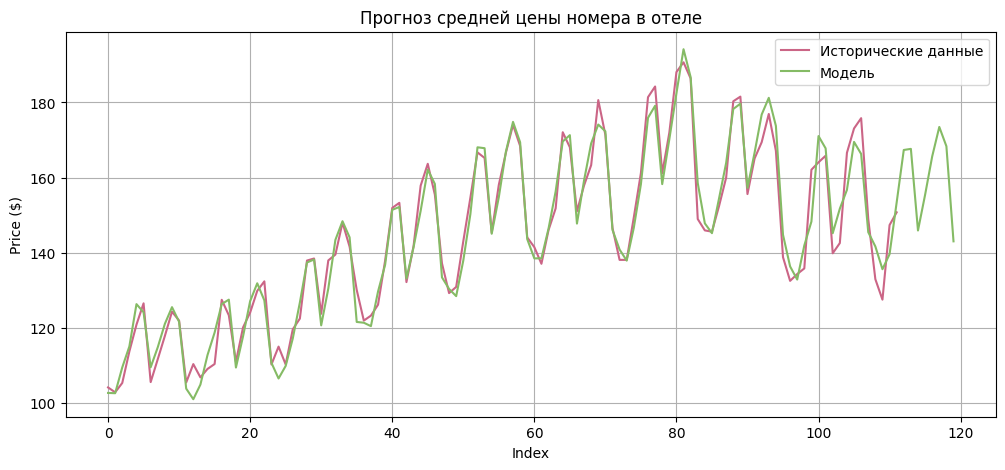

In [103]:
# Построим график
plt.figure(figsize=(12,5))

plt.plot(np.asarray(y), label='Исторические данные', color='#CB6586')
plt.plot(fitted_, label='Модель', color='#85BB65')

plt.legend()
plt.grid()
plt.xlabel('Index')
plt.ylabel('Price ($)')
plt.title('Прогноз средней цены номера в отеле')
plt.style.use('ggplot')
plt.show()

Анализируя график, можно отметить, что модель (зеленая линия) хорошо повторяет исторические данные, что говорит о том, что выбранная модель (экспоненциальное сглаживание с трендом и сезонностью) адекватно описывает структуру ряда.

Желтая линия показывает прогноз на следующие 8 месяцев. Можно отметить, что цены продолжают колебаться сезонно, а также остаются на высоком уровне (~ 150-170$), что согласуется с последними наблюдениями.

In [96]:
# Прогноз на 8 месяцев
fitted_[112:120]

array([167.33827976, 167.63426848, 145.87770941, 155.37676992,
       165.62224942, 173.47779584, 168.33158463, 142.98465526])

In [97]:
# Параметры модели
fit.params

{'smoothing_level': np.float64(0.5142885131708934),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': np.float64(0.9905168799360904),
 'initial_level': np.float64(113.21642956796659),
 'initial_trend': np.float64(0.5603505029279093),
 'initial_seasons': array([0.90157466, 0.89006011, 0.94421424, 1.00746874, 1.10770876,
        1.1082807 , 0.96324864, 1.02471669, 1.09096379, 1.14134017,
        1.10617011, 0.93850443]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [106]:
fitted_ = fit.fittedvalues

mae = mean_absolute_error(y, fitted_)
rmse = np.sqrt(mean_squared_error(y, fitted_))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.4066693040468508
RMSE: 4.385772567142788


Средняя абсолютная ошибка модели составляет около 3.4 доллара, что свидетельствует о достаточно высокой точности модели.
Значение RMSE (4.8) превышает MAE (3.4), что указывает на наличие отдельных более крупных ошибок прогноза.